<a href="https://colab.research.google.com/github/duartegonzaloariel/UDELAR_Astrometric-calibration-/blob/main/sky_coordinates_prediction3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

.

.# SKY COORDINATES PREDICTION
---


# 0. Initialization

## 0.1. Libraries

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
#from torchinfo import summary
from torch.nn import TransformerEncoder, TransformerEncoderLayer

from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn.preprocessing import MinMaxScaler, StandardScaler
import scipy.stats as stats

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os

from google.colab import drive

## 0.2. PLATFORM

In [ ]:
VERBOSE = True
RANDOM_STATE = 42
torch.manual_seed(RANDOM_STATE)
cuda_available = torch.cuda.is_available()
print(f"CUDA Available:  {cuda_available}")

if cuda_available:
    device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
    print(f"GPU Device:\t {torch.cuda.get_device_name(0)}")
    mem_free, mem_total = torch.cuda.mem_get_info(device)
    # Convertir a MB
    mem_free_MB = mem_free / (1024 ** 3)
    mem_total_MB = mem_total / (1024 ** 3)
    print(f"Memoria libre: \t {mem_free_MB:.2f} GB")
    print(f"Memoria total: \t {mem_total_MB:.2f} GB")
    print(f"Memoria usada: \t {mem_total_MB - mem_free_MB:.2f} GB")
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')

print('Selected device:',device)

CUDA Available:  False
Selected device: cpu


## 0.3. Drive

In [ ]:
# Monta tu unidad de Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


# 1. DATOS

In [ ]:
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

**CONFIGURACION**

---



In [ ]:
SPLIT_TRAIN_TEST = 0.2
RANDOM_SEED      = 40
BATCH            = 32
EPOCHS = 1000
LOOPS  = 5

DATA_NORMALIZATION   = True
DATA_AUGMENTATION    = False
DATA_FILTER_OUTLIERS = False

# Modelo
model_name = 'DENSE'  # 'RNN','DENSE','DENSE_BAYESIAN', 'CNN'

# Configuración de pérdida y optimizador
criterion = nn.MSELoss()

# =========================
# TARGET DATA
# =========================
TASK = "A"  # "A" para (X,Y)->(az,zen), "B" para (az,zen)->(X,Y)

# one-hot de station (las que vos dijiste que existen)
STATION_ONEHOT_COLS = [
    'station_1','station_2','station_3','station_4','station_5','station_6','station_7','station_8',
    'station_9','station_10','station_12','station_13','station_14','station_15','station_16','station_17',
    'station_19','station_20'
]

# features base comunes
BASE_FEATURES = [
    'd_center',
    'año',
    'mes_sin',
    'mes_cos'
]

if TASK == "A":
    # (X,Y)->(az,zen)
    COLUMNS_DATA   = ['Posicion_X', 'Posicion_Y'] + BASE_FEATURES + STATION_ONEHOT_COLS
    COLUMNS_TARGET = ['azimuth_sin', 'azimuth_cos', 'zenith']
    #COLUMNS_TARGET = ['azimuth', 'zenith']

elif TASK == "B":
    # (az,zen)->(X,Y)
    COLUMNS_DATA   = ['azimuth', 'zenith'] + BASE_FEATURES + STATION_ONEHOT_COLS
    COLUMNS_TARGET = ['Posicion_X', 'Posicion_Y']

else:
    raise ValueError("TASK debe ser 'A' o 'B'.")

OUTPUT_SIZE = len(COLUMNS_TARGET)
np.random.seed(RANDOM_SEED)


## 1.1. Carga y Preparación de los Datos

### 1.1.1. Load CSV in Dataframes

In [ ]:
# Configuración de ruta y tipo de archivo
PATH_BASE = "/content/drive/MyDrive/InvestigacionesPropias/Fireball/estrellas/calibracion/"
tipo_tabla = "csv"  # Cambiar a "csv" para procesar CSV


El código une varios archivos (CSV o Excel) con datos de coordenadas, les agrega un identificador y calcula para cada punto su distancia y ángulo respecto al centro (774, 520), mostrando luego un resumen del DataFrame final.

In [ ]:
# Coordenadas del centro
X0 = 1548 // 2
Y0 = 1040 // 2
nombre = 'df_global'
# Manejo de archivos CSV
if tipo_tabla == "csv":
    csv_files = [f for f in os.listdir(PATH_BASE) if f.endswith('.csv') and f.startswith(nombre)]

    df_list = []
    print('CSV FILE LIST\n---------------')
    for ix, file in enumerate(csv_files):
        file_path = os.path.join(PATH_BASE, file)
        df_file = pd.read_csv(file_path)
        df_file['csv'] = (np.ones(len(df_file)) * ix).astype(int)
        print(file_path, '\tN Samples: ', len(df_file))

        df_list.append(df_file)

    data_df = pd.concat(df_list, ignore_index=True)

# Manejo de archivos Excel
elif tipo_tabla == "excel":
    excel_files = [f for f in os.listdir(PATH_BASE) if f.endswith('.xlsx') or f.endswith('.xls')]

    df_list = []
    print('EXCEL FILE LIST\n---------------')
    for ix, file in enumerate(excel_files):
        file_path = os.path.join(PATH_BASE, file)
        df_file = pd.read_excel(file_path)
        df_file['excel'] = (np.ones(len(df_file)) * ix).astype(int)
        print(file_path, '\tN Samples: ', len(df_file))

        df_list.append(df_file)

    data_df = pd.concat(df_list, ignore_index=True)

# Cálculos adicionales
data_df['d_center'] = np.sqrt((data_df['Posicion_X'] - X0)**2 + (data_df['Posicion_Y'] - Y0)**2)
data_df['angle'] = np.degrees(np.arctan2(data_df['Posicion_Y'] - Y0, data_df['Posicion_X'] - X0))

# Información del DataFrame
print('\nDATAFRAME INFO:\n----------------')
print(data_df.info())
print('\nSAMPLES:\n---------\n', data_df.sample())

CSV FILE LIST
---------------
/content/drive/MyDrive/InvestigacionesPropias/Fireball/estrellas/calibracion/df_global.csv 	N Samples:  8870

DATAFRAME INFO:
----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8870 entries, 0 to 8869
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   station         8870 non-null   int64  
 1   año             8870 non-null   int64  
 2   mes             8870 non-null   int64  
 3   Posicion_Y      8870 non-null   int64  
 4   Posicion_X      8870 non-null   int64  
 5   azimuth         8870 non-null   float64
 6   altitude        8870 non-null   float64
 7   Posicion_Ypred  8870 non-null   int64  
 8   Posicion_Xpred  8870 non-null   int64  
 9   csv             8870 non-null   int64  
 10  d_center        8870 non-null   float64
 11  angle           8870 non-null   float64
dtypes: float64(4), int64(8)
memory usage: 831.7 KB
None

SAMPLES:
---------
       statio

In [ ]:
data_df.head()

,station,año,mes,Posicion_Y,Posicion_X,azimuth,altitude,Posicion_Ypred,Posicion_Xpred,csv,d_center,angle
0,1,2022,9,541,869,158.494,76.494,556,885,0,97.293371,12.464933
1,1,2022,9,486,867,184.884,77.475,504,881,0,99.020200,-20.081977
2,1,2022,9,586,710,65.015,79.503,604,741,0,91.934759,134.118596
3,1,2022,9,734,1038,139.870,49.255,729,1056,0,339.841139,39.028434
4,1,2022,9,279,1191,205.629,35.018,289,1187,0,481.632640,-30.025234


In [ ]:
import numpy as np
data_df['mes_sin'] = np.sin(2 * np.pi * data_df['mes'] / 12)
data_df['mes_cos'] = np.cos(2 * np.pi * data_df['mes'] / 12)
data_df = data_df.drop(columns=['mes'])
data_df.head()

,station,año,Posicion_Y,Posicion_X,azimuth,altitude,Posicion_Ypred,Posicion_Xpred,csv,d_center,angle,mes_sin,mes_cos
0,1,2022,541,869,158.494,76.494,556,885,0,97.293371,12.464933,-1.0,-1.836970e-16
1,1,2022,486,867,184.884,77.475,504,881,0,99.020200,-20.081977,-1.0,-1.836970e-16
2,1,2022,586,710,65.015,79.503,604,741,0,91.934759,134.118596,-1.0,-1.836970e-16
3,1,2022,734,1038,139.870,49.255,729,1056,0,339.841139,39.028434,-1.0,-1.836970e-16
4,1,2022,279,1191,205.629,35.018,289,1187,0,481.632640,-30.025234,-1.0,-1.836970e-16


In [ ]:
# Obtener columnas binarias
dummy_columns = pd.get_dummies(data_df['station'], prefix='station', dtype=int)

# Concatenar al DataFrame original
data_df = pd.concat([data_df, dummy_columns], axis=1)

# Eliminar la columna original 'Pclass'
data_df.drop('station', axis=1, inplace=True)

# Mostrar el DataFrame resultante
data_df.head()

,año,Posicion_Y,Posicion_X,azimuth,altitude,Posicion_Ypred,Posicion_Xpred,csv,d_center,angle,mes_sin,mes_cos,station_1,station_2,station_3,station_4,station_5,station_6,station_7,station_8,station_9,station_10,station_12,station_13,station_14,station_15,station_16,station_17,station_19,station_20
0,2022,541,869,158.494,76.494,556,885,0,97.293371,12.464933,-1.0,-1.836970e-16,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,2022,486,867,184.884,77.475,504,881,0,99.020200,-20.081977,-1.0,-1.836970e-16,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,2022,586,710,65.015,79.503,604,741,0,91.934759,134.118596,-1.0,-1.836970e-16,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,2022,734,1038,139.870,49.255,729,1056,0,339.841139,39.028434,-1.0,-1.836970e-16,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,2022,279,1191,205.629,35.018,289,1187,0,481.632640,-30.025234,-1.0,-1.836970e-16,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [ ]:
theta = np.deg2rad(data_df['azimuth'])
data_df['azimuth_sin'] = np.sin(theta)
data_df['azimuth_cos'] = np.cos(theta)
data_df = data_df.drop(columns=['azimuth'])


In [ ]:
data_df.isnull().sum()

,0
año,0
Posicion_Y,0
Posicion_X,0
altitude,0
Posicion_Ypred,0
Posicion_Xpred,0
csv,0
d_center,0
angle,0
mes_sin,0


In [ ]:
data_df.shape

(8870, 31)

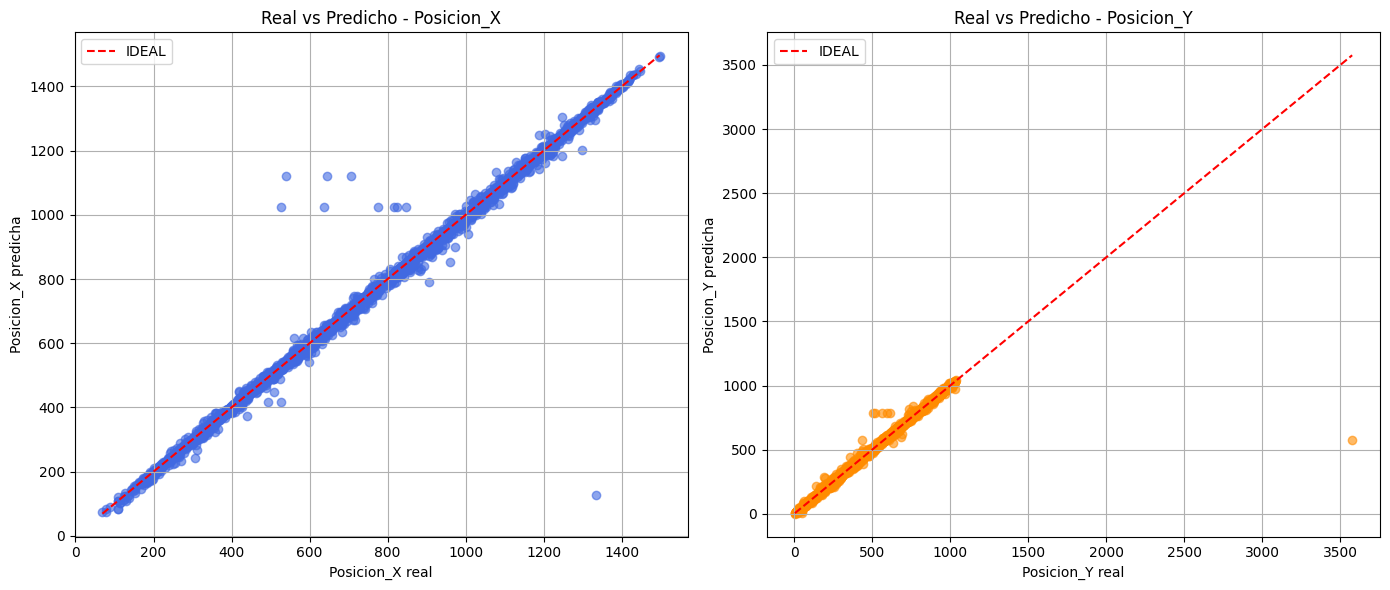

In [ ]:
plt.figure(figsize=(14,6))

# ----- X -----
plt.subplot(1,2,1)
plt.scatter(data_df['Posicion_X'], data_df['Posicion_Xpred'], alpha=0.6, color='royalblue')
plt.plot([data_df['Posicion_X'].min(), data_df['Posicion_X'].max()],
         [data_df['Posicion_X'].min(), data_df['Posicion_X'].max()],
         'r--', label='IDEAL')
plt.xlabel('Posicion_X real')
plt.ylabel('Posicion_X predicha')
plt.title('Real vs Predicho - Posicion_X')
plt.legend()
plt.grid(True)

# ----- Y -----
plt.subplot(1,2,2)
plt.scatter(data_df['Posicion_Y'], data_df['Posicion_Ypred'], alpha=0.6, color='darkorange')
plt.plot([data_df['Posicion_Y'].min(), data_df['Posicion_Y'].max()],
         [data_df['Posicion_Y'].min(), data_df['Posicion_Y'].max()],
         'r--', label='IDEAL')
plt.xlabel('Posicion_Y real')
plt.ylabel('Posicion_Y predicha')
plt.title('Real vs Predicho - Posicion_Y')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


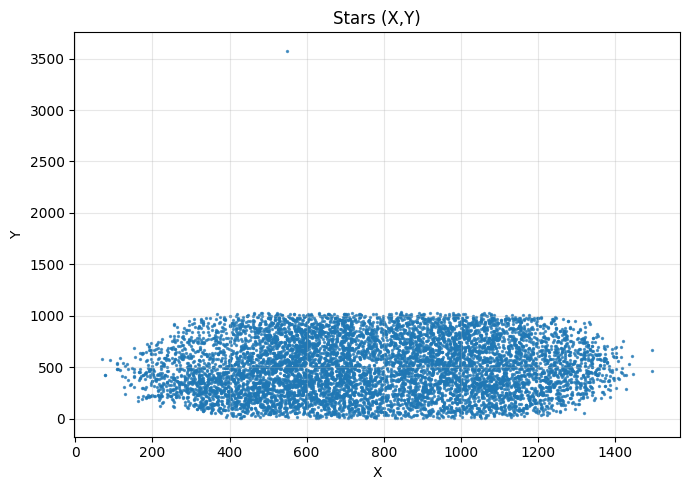

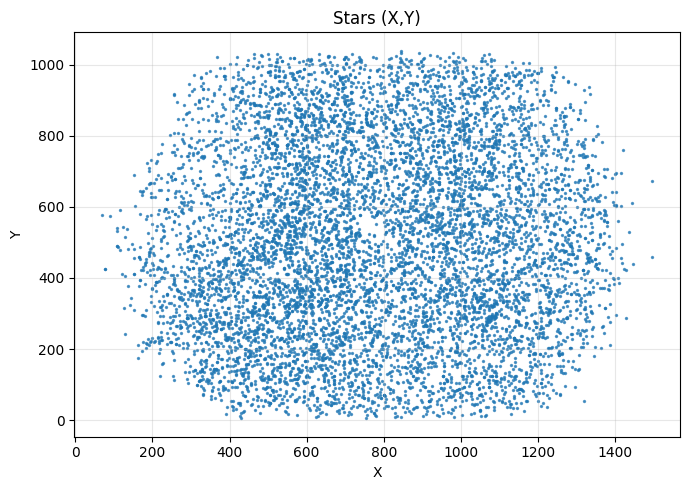

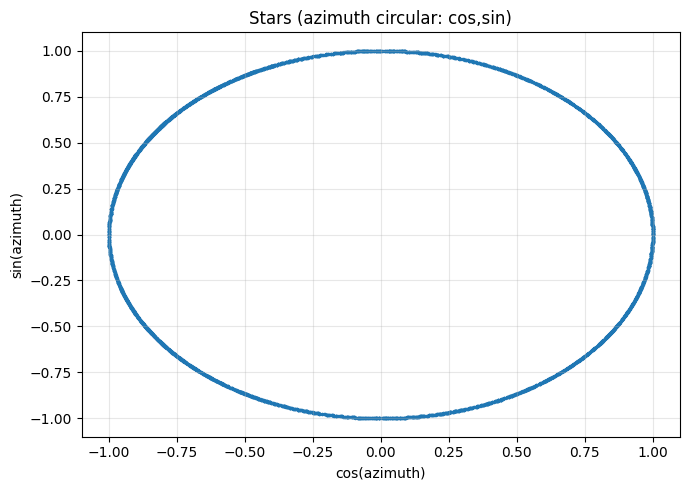

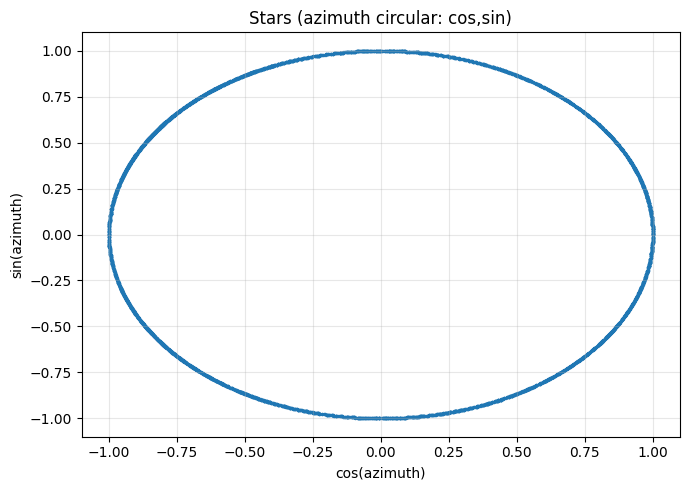

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN

# ==========================================
# PRE: completar columnas si faltan
# ==========================================
def agregar_columnas_derivadas(data):
    data = data.copy()

    if 'Nombre' not in data.columns:
        data['Nombre'] = 'sin nombre'

    if 'zenith' not in data.columns:
        if 'altitude' in data.columns:
            data['zenith'] = 90.0 - data['altitude']
        else:
            print("Advertencia: No existe 'zenith' ni 'altitude'.")

    if ('azimuth_sin' not in data.columns) or ('azimuth_cos' not in data.columns):
        if 'azimuth' in data.columns:
            theta = np.deg2rad(data['azimuth'].astype(float))
            data['azimuth_sin'] = np.sin(theta)
            data['azimuth_cos'] = np.cos(theta)
        else:
            print("Advertencia: No existe 'azimuth'.")

    return data


# ==========================================
# PLOT (SOLO CAMBIO VISUAL)
# - sin nombres
# - puntos muy pequeños
# - figura < 1/2 tamaño original
# ==========================================
def plot_Stars(dataframe, TASK="A", max_labels=5000):
    plt.figure(figsize=(7, 5))   # <<<<<< menos de la mitad (antes 18x12)

    if TASK == "A":
        xcol, ycol = 'Posicion_X', 'Posicion_Y'
        xlabel, ylabel = 'X', 'Y'
        title = 'Stars (X,Y)'

    elif TASK == "B":
        xcol, ycol = 'azimuth_cos', 'azimuth_sin'
        xlabel, ylabel = 'cos(azimuth)', 'sin(azimuth)'
        title = 'Stars (azimuth circular: cos,sin)'

    else:
        raise ValueError("TASK debe ser 'A' o 'B'.")

    faltan = [c for c in [xcol, ycol] if c not in dataframe.columns]
    if faltan:
        raise ValueError(f"Faltan columnas: {faltan}")

    # ---- SOLO CAMBIO ----
    plt.scatter(
        dataframe[xcol],
        dataframe[ycol],
        s=2,          # puntos MUY chicos
        alpha=0.7
    )
    # --------------------

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


# ==========================================
# DBSCAN
# ==========================================
def detectar_ruido_dbscan(
    df,
    TASK="A",
    eps=0.35,
    min_samples=25,
    eliminar_outliers=True
):
    df = df.copy()

    if TASK == "A":
        cols = ['Posicion_X', 'Posicion_Y']
    elif TASK == "B":
        cols = ['azimuth_sin', 'azimuth_cos', 'zenith']
    else:
        raise ValueError("TASK debe ser 'A' o 'B'.")

    X = df[cols].astype(float).values
    Xs = StandardScaler().fit_transform(X)

    db = DBSCAN(eps=eps, min_samples=min_samples)
    labels = db.fit_predict(Xs)

    df['cluster'] = labels
    df['is_noise'] = (labels == -1)

    df_eliminados = df[df['is_noise']].copy()
    df_limpio = df[~df['is_noise']].copy()

    if eliminar_outliers:
        return df_limpio.reset_index(drop=True), df_eliminados.reset_index(drop=True), cols
    else:
        return df.reset_index(drop=True), df_eliminados.reset_index(drop=True), cols


# ==========================================
# PIPELINE
# ==========================================
def pipeline_dbscan_doble_paso(
    data_df,
    eps_A=0.35,
    min_samples_A=25,
    eps_B=0.35,
    min_samples_B=25,
    graficar=True,
    max_labels=5000
):
    df0 = agregar_columnas_derivadas(data_df)

    if graficar:
        plot_Stars(df0, TASK="A")

    dfA, elimA, _ = detectar_ruido_dbscan(
        df0, TASK="A",
        eps=eps_A, min_samples=min_samples_A
    )

    if graficar:
        plot_Stars(dfA, TASK="A")

    if graficar:
        plot_Stars(dfA, TASK="B")

    dfB, elimB, _ = detectar_ruido_dbscan(
        dfA, TASK="B",
        eps=eps_B, min_samples=min_samples_B
    )

    if graficar:
        plot_Stars(dfB, TASK="B")

    return dfB, elimA, elimB


# =========================
# USO
# =========================
df_final, elimA, elimB = pipeline_dbscan_doble_paso(
    data_df,
    eps_A=0.35,
    min_samples_A=25,
    eps_B=0.35,
    min_samples_B=25,
    graficar=True
)



In [ ]:
list(data_df.columns)

['año',
 'Posicion_Y',
 'Posicion_X',
 'altitude',
 'Posicion_Ypred',
 'Posicion_Xpred',
 'csv',
 'd_center',
 'angle',
 'mes_sin',
 'mes_cos',
 'station_1',
 'station_2',
 'station_3',
 'station_4',
 'station_5',
 'station_6',
 'station_7',
 'station_8',
 'station_9',
 'station_10',
 'station_12',
 'station_13',
 'station_14',
 'station_15',
 'station_16',
 'station_17',
 'station_19',
 'station_20',
 'azimuth_sin',
 'azimuth_cos']

### 1.1.2. Split TRAIN / TEST data


El código utiliza train_test_split de Scikit-learn para dividir el conjunto de datos data_df en dos partes: 80% para entrenamiento (train_df) y 20% para prueba (test_df), según el valor de TEST_SIZE

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================
# CONFIG
# =========================
TEST_SIZE   = 0.2
RANDOM_SEED = 42

TASK = "A"   # "A": y = [Posicion_X, Posicion_Y]
             # "B": y = [azimuth, zenith]

USE_PRED_AS_FEATURES = False  # True si querés incluir Posicion_Xpred/Posicion_Ypred en X

# =========================
# DATA
# =========================
df = data_df  # usás tu DF tal cual

# =========================
# COLUMNAS (TU LISTA, SIN CAMBIOS)
# =========================
ALL_COLS = [
    'año',
    'Posicion_Y',
    'Posicion_X',
    'azimuth',
    'altitude',
    'Posicion_Ypred',
    'Posicion_Xpred',
    'csv',
    'd_center',
    'angle',
    'mes_sin',
    'mes_cos',
    'Nombre',
    'zenith',
    'cluster',
    'is_noise',
    'station_1',
    'station_2',
    'station_3',
    'station_4',
    'station_5',
    'station_6',
    'station_7',
    'station_8',
    'station_9',
    'station_10',
    'station_12',
    'station_13',
    'station_14',
    'station_15',
    'station_16',
    'station_17',
    'station_19',
    'station_20'
]

# =========================
# TARGETS (y)
# =========================
if TASK == "A":
    y_cols = ['Posicion_X', 'Posicion_Y']
elif TASK == "B":
    y_cols = ['azimuth', 'zenith']
else:
    raise ValueError("TASK debe ser 'A' o 'B'.")

# =========================
# FEATURES (X) - ELEGIDAS
# =========================
station_cols = [
    'station_1','station_2','station_3','station_4','station_5','station_6','station_7','station_8',
    'station_9','station_10','station_12','station_13','station_14','station_15','station_16','station_17',
    'station_19','station_20'
]

# Features numéricas "reales" + mes cíclico + estación one-hot
X_cols = [
    'año',
    'mes_sin', 'mes_cos',
    'd_center',
    'angle',
    'altitude',
] + station_cols

# (Opcional) incluir predicciones previas como features
if USE_PRED_AS_FEATURES:
    X_cols += ['Posicion_Xpred', 'Posicion_Ypred']

# =========================
# ARMAR DF DEL MODELO (sin checks)
# =========================
df_model = df[X_cols + y_cols].copy()

# =========================
# SPLIT
# =========================
train_df, test_df = train_test_split(
    df_model,
    test_size=TEST_SIZE,
    random_state=RANDOM_SEED
)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)

# =========================
# X / y
# =========================
X_train = train_df[X_cols].copy()
y_train = train_df[y_cols].copy()

X_test  = test_df[X_cols].copy()
y_test  = test_df[y_cols].copy()

# =========================
# ESCALADO (solo numéricas, NO one-hot)
# =========================
num_cols_to_scale = ['año', 'mes_sin', 'mes_cos', 'd_center', 'angle', 'altitude']
if USE_PRED_AS_FEATURES:
    num_cols_to_scale += ['Posicion_Xpred', 'Posicion_Ypred']

scaler = StandardScaler()
X_train[num_cols_to_scale] = scaler.fit_transform(X_train[num_cols_to_scale])
X_test[num_cols_to_scale]  = scaler.transform(X_test[num_cols_to_scale])

# =========================
# OUTPUT
# =========================
print("\nX_cols (features):", X_cols)
print("y_cols (targets): ", y_cols)
print("\nX_train:", X_train.shape, "y_train:", y_train.shape)
print("X_test: ", X_test.shape,  "y_test: ", y_test.shape)


Train shape: (7096, 26)
Test shape:  (1774, 26)

X_cols (features): ['año', 'mes_sin', 'mes_cos', 'd_center', 'angle', 'altitude', 'station_1', 'station_2', 'station_3', 'station_4', 'station_5', 'station_6', 'station_7', 'station_8', 'station_9', 'station_10', 'station_12', 'station_13', 'station_14', 'station_15', 'station_16', 'station_17', 'station_19', 'station_20']
y_cols (targets):  ['Posicion_X', 'Posicion_Y']

X_train: (7096, 24) y_train: (7096, 2)
X_test:  (1774, 24) y_test:  (1774, 2)


##1.2. Preparación de datos y carga

Selección de variables de entrada y de salida según la tarea definida (TASK A o TASK B).

Codificación temporal del mes mediante una representación cíclica (mes_sin, mes_cos).

Codificación de la estación mediante representación one-hot (station_*).

División del conjunto de datos en entrenamiento y prueba utilizando una semilla fija para garantizar reproducibilidad.

Normalización de las variables continuas mediante estandarización (media = 0, desviación estándar = 1).

Aplicación opcional de aumento de datos mediante la adición de ruido gaussiano sobre variables continuas.

Aplicación opcional de filtrado de valores atípicos (outliers) utilizando el criterio de z-score aplicado por filas.

Construcción de los objetos Dataset y DataLoader de PyTorch para el entrenamiento y la evaluación del modelo.

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import torch
from torch.utils.data import Dataset, DataLoader


# =========================
# CONFIG
# =========================
SPLIT_TRAIN_TEST = 0.15
RANDOM_SEED      = 40
BATCH            = 32

EPOCHS = 1000
LOOPS  = 5

DATA_NORMALIZATION   = True
DATA_AUGMENTATION    = False
DATA_FILTER_OUTLIERS = False

TASK = "A"  # "A": (X,Y)->(az,zen)   |   "B": (az,zen)->(X,Y)


# =========================
# DATAFRAME BASE
# =========================
df = data_df.copy()

# =========================
# COLUMNAS DERIVADAS (NUEVAS)
# =========================
# zenith desde altitude si falta
if 'zenith' not in df.columns:
    if 'altitude' in df.columns:
        df['zenith'] = 90.0 - df['altitude'].astype(float)
    else:
        raise ValueError("No existe 'zenith' ni 'altitude'. Necesito una de las dos.")

# azimuth_sin/cos desde azimuth (necesario para TASK A y B)
if ('azimuth_sin' not in df.columns) or ('azimuth_cos' not in df.columns):
    if 'azimuth' in df.columns:
        theta = np.deg2rad(df['azimuth'].astype(float))
        df['azimuth_sin'] = np.sin(theta)
        df['azimuth_cos'] = np.cos(theta)
    else:
        raise ValueError("No existe 'azimuth'. No se puede construir azimuth_sin/cos.")


# =========================
# COLUMNAS (FIJAS)
# =========================
STATION_ONEHOT_COLS = [
    'station_1','station_2','station_3','station_4','station_5','station_6','station_7','station_8',
    'station_9','station_10','station_12','station_13','station_14','station_15','station_16','station_17',
    'station_19','station_20'
]

BASE_FEATURES = [
    'd_center',
    'angle',
    'altitude',   # la mantenemos como feature si existe
    'año',
    'mes_sin',
    'mes_cos'
]

# =========================
# INPUT / TARGET según TASK (ACTUALIZADO)
# =========================
if TASK == "A":
    # (X,Y) -> (azimuth circular, zenith)
    COLUMNS_DATA   = ['Posicion_X', 'Posicion_Y'] + BASE_FEATURES + STATION_ONEHOT_COLS
    COLUMNS_TARGET = ['azimuth_sin', 'azimuth_cos', 'zenith']

elif TASK == "B":
    # (azimuth circular, zenith) -> (X,Y)
    COLUMNS_DATA   = ['azimuth_sin', 'azimuth_cos', 'zenith'] + BASE_FEATURES + STATION_ONEHOT_COLS
    COLUMNS_TARGET = ['Posicion_X', 'Posicion_Y']

else:
    raise ValueError("TASK debe ser 'A' o 'B'.")

OUTPUT_SIZE = len(COLUMNS_TARGET)

np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)


# =========================
# DF MODEL (features + targets + metadata)
# =========================
df_model = df[COLUMNS_DATA + COLUMNS_TARGET  ].copy() #+['Nombre', 'csv']


# =========================
# SPLIT TRAIN / TEST
# =========================
train_df, test_df = train_test_split(
    df_model,
    test_size=SPLIT_TRAIN_TEST,
    random_state=RANDOM_SEED
)

train_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

print("Train shape:", train_df.shape)
print("Test shape: ", test_df.shape)


# =========================
# NORMALIZACIÓN
# - Escalamos SOLO inputs continuos
# - NO escalamos azimuth_sin/cos (ya están en [-1, 1])
# =========================
continuous_cols = [
    'd_center','angle','altitude','año','mes_sin','mes_cos',
    'Posicion_X','Posicion_Y','zenith'
    # NOTA: azimuth_sin/cos NO se agregan acá
]

cols_scale = [c for c in COLUMNS_DATA if c in continuous_cols]

scaler = None
if DATA_NORMALIZATION and len(cols_scale) > 0:
    scaler = StandardScaler()

    scaled_train = scaler.fit_transform(train_df[cols_scale].values)
    scaled_test  = scaler.transform(test_df[cols_scale].values)

    for i, col in enumerate(cols_scale):
        train_df[col] = scaled_train[:, i].astype('float32')
        test_df[col]  = scaled_test[:, i].astype('float32')


# =========================
# DATA AUGMENTATION
# =========================
def augment_with_noise(arr, noise_level=0.01):
    noise = np.random.normal(loc=0.0, scale=noise_level, size=arr.shape)
    return arr + noise

if DATA_AUGMENTATION:
    no_noise_exact = {'año', 'mes_sin', 'mes_cos'}

    for col in COLUMNS_DATA:
        if col in no_noise_exact:
            continue
        if col.startswith("station_"):
            continue
        # NO meter ruido a sin/cos del azimuth
        if col in {'azimuth_sin', 'azimuth_cos'}:
            continue
        if col in continuous_cols:
            train_df.loc[:, col] = augment_with_noise(
                train_df[col].values, noise_level=0.01
            )


# =========================
# FILTRO DE OUTLIERS (POR FILAS)
# =========================
if DATA_FILTER_OUTLIERS:
    THRESHOLD = 3.0

    cols_z = [
        c for c in COLUMNS_DATA
        if (c in continuous_cols) and (not c.startswith("station_"))
    ]

    Z = np.abs(stats.zscore(train_df[cols_z], nan_policy='omit'))
    mask = (Z < THRESHOLD) if Z.ndim == 1 else (Z < THRESHOLD).all(axis=1)

    before = len(train_df)
    train_df = train_df.loc[mask].reset_index(drop=True)
    after = len(train_df)

    print(f"[INFO] Outliers filtrados: {before-after} filas removidas. Quedan {after}.")


# =========================
# DATASET / DATALOADER
# =========================
class SkyDataset(Dataset):
    def __init__(self, dataframe, feature_columns, label_columns):
        self.df = dataframe.reset_index(drop=True)

        self.features = self.df.loc[:, feature_columns].values.astype('float32')
        self.targets  = self.df.loc[:, label_columns].values.astype('float32')

        #self.names = self.df['Nombre'].astype(str).values
        #self.csv   = self.df['csv'].astype(str).values

    def __len__(self):
        return len(self.features)

    def __getitem__(self, idx):
        return {
            'features': torch.tensor(self.features[idx]),
            'targets' : torch.tensor(self.targets[idx]),
            #'names'   : self.names[idx],
            #'csv'     : self.csv[idx],
            'idx'     : idx
        }


train_dataset = SkyDataset(train_df, COLUMNS_DATA, COLUMNS_TARGET)
test_dataset  = SkyDataset(test_df,  COLUMNS_DATA, COLUMNS_TARGET)

train_loader = DataLoader(train_dataset, batch_size=BATCH, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH, shuffle=False)


# =========================
# DEBUG FINAL
# =========================
sample = train_dataset[0]
batch  = next(iter(train_loader))

print("\nCOLUMNS_DATA (features):", len(COLUMNS_DATA))
print("COLUMNS_TARGET (targets):", len(COLUMNS_TARGET))
print("Train Dataset Length:", len(train_dataset))
print("Test Dataset Length: ", len(test_dataset))
print("Sample features shape:", sample['features'].shape,
      "| sample targets shape:", sample['targets'].shape)
print("Batch features shape:", batch['features'].shape,
      "| batch targets shape:", batch['targets'].shape)


Train shape: (7539, 29)
Test shape:  (1331, 29)

COLUMNS_DATA (features): 26
COLUMNS_TARGET (targets): 3
Train Dataset Length: 7539
Test Dataset Length:  1331
Sample features shape: torch.Size([26]) | sample targets shape: torch.Size([3])
Batch features shape: torch.Size([32, 26]) | batch targets shape: torch.Size([32, 3])


# 2. Network Dense

## 2.1. Network Dense Model

### 2.1.1. Modelos

####**Modelo Neuronal Denso**

---

cada neurona de una capa está conectada a todas las neuronas de la siguiente capa. Esto significa que la información fluye a través de todas las conexiones posibles entre capas, lo que permite capturar relaciones complejas entre las características de los datos.

In [ ]:
class SkyCoordinatesModel(nn.Module):
    def __init__(self, input_size, output_size):
        super(SkyCoordinatesModel, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Linear(128, 256),

            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, output_size)
        )

    def forward(self, x):

        return self.network(x)

# Instanciar el modelo
model_dense = SkyCoordinatesModel(input_size = len(COLUMNS_DATA), output_size = OUTPUT_SIZE).to(device)
print('Model Device:', next(model_dense.parameters()).device, '\n')
print(model_dense)
# summary(model, input_size=(1,2))  # Batch size = 1, Data Shape = (2)


Model Device: cpu 

SkyCoordinatesModel(
  (network): Sequential(
    (0): Linear(in_features=26, out_features=128, bias=True)
    (1): ReLU()
    (2): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): Linear(in_features=128, out_features=256, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): ReLU()
    (8): Linear(in_features=128, out_features=3, bias=True)
  )
)


####**Modelo Neuronal Bayesiano**

---

Este modelo implementa una una capa lineal bayesiana en lugar de una capa densa tradicional. Donde los pesos y los sesgos no son valores fijos, sino distribuciones probabilísticas, lo que permite capturar la incertidumbre en los parámetros del modelo y facilitar el aprendizaje bajo condiciones inciertas.








In [ ]:
# --- Corrección completa (robusta y lista para usar) ---
import torch
import torch.nn as nn
import torch.nn.functional as F

class BayesianLinear(nn.Module):
    def __init__(self, in_features, out_features, init_logvar=-8.0):
        super().__init__()
        # Medias
        self.weight_mu = nn.Parameter(torch.zeros(out_features, in_features))
        self.bias_mu   = nn.Parameter(torch.zeros(out_features))
        # Varianzas log (menos extremas que -10 para permitir aprender incertidumbre)
        self.weight_logvar = nn.Parameter(torch.ones(out_features, in_features) * init_logvar)
        self.bias_logvar   = nn.Parameter(torch.ones(out_features) * init_logvar)

    def forward(self, x):
        # Reparametrización: mu + sigma * eps
        weight_std = torch.exp(0.5 * self.weight_logvar)
        bias_std   = torch.exp(0.5 * self.bias_logvar)

        weight = self.weight_mu + weight_std * torch.randn_like(weight_std)
        bias   = self.bias_mu   + bias_std   * torch.randn_like(bias_std)

        return F.linear(x, weight, bias)

class BayesianSkyCoordinatesModel(nn.Module):
    """
    Tronco compartido + 'heads' por salida (mejor para sesgos distintos en X e Y).
    Si output_size == 1 -> una sola head. Si >1 -> N heads y se concatenan.
    """
    def __init__(self, input_size, output_size):
        super().__init__()
        self.trunk = nn.Sequential(
            BayesianLinear(input_size, 128),
            nn.ReLU(),
            nn.LayerNorm(128),           # más estable que BatchNorm con batches chicos
            BayesianLinear(128, 256),
            nn.ReLU(),
            nn.Dropout(0.30),
            BayesianLinear(256, 128),
            nn.ReLU(),
        )
        if output_size == 1:
            self.heads = nn.ModuleList([BayesianLinear(128, 1)])
        else:
            self.heads = nn.ModuleList([BayesianLinear(128, 1) for _ in range(output_size)])

    def forward(self, x):
        h = self.trunk(x)
        outs = [head(h) for head in self.heads]
        return torch.cat(outs, dim=1)

# Instanciación
model_Bayes = BayesianSkyCoordinatesModel(
    input_size  = len(COLUMNS_DATA),
    output_size = OUTPUT_SIZE
).to(device)

print('Model Device:', next(model_Bayes.parameters()).device, '\n')
print(model_Bayes)


Model Device: cpu 

BayesianSkyCoordinatesModel(
  (trunk): Sequential(
    (0): BayesianLinear()
    (1): ReLU()
    (2): LayerNorm((128,), eps=1e-05, elementwise_affine=True)
    (3): BayesianLinear()
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): BayesianLinear()
    (7): ReLU()
  )
  (heads): ModuleList(
    (0-2): 3 x BayesianLinear()
  )
)


####**Modelo Convolucional**

---
Red neuronal que usa operaciones de convolución en lugar de las conexiones totalmente conectadas típicas de las redes neuronales tradicionales. Las CNN son muy efectivas para tareas de procesamiento de imágenes, pero también se pueden aplicar a otros tipos de datos como series temporales o datos tabulares con ciertas estructuras.



In [ ]:
class CNNModel(nn.Module):
    def __init__(self,input_size, output_size):
        super(CNNModel, self).__init__()
        self.conv = nn.Conv1d(in_channels=input_size, out_channels=16, kernel_size=3, padding=1)
        self.fc = nn.Linear(16, output_size)

    def forward(self, x):
        x = x.unsqueeze(2)
        x = self.conv(x)
        x = torch.relu(x)
        x = x.mean(dim=-1)  # Global Average Pooling
        x = self.fc(x)
        return x


####**Modelo Recurrente con Atención**

---

El modelo RNNModel es una red neuronal secuencial que combina una capa recurrente (RNN, LSTM o GRU) con un mecanismo de atención para mejorar la capacidad de la red para enfocarse en las partes más relevantes de la secuencia de entrada.


**Interpretacion**


Aunque no se tengan secuencias temporales en los datos, las redes recurrentes pueden seguir siendo útiles si las relaciones entre las características son complejas.

* *Captura de interacciones no lineales:* Las redes recurrentes, incluso sin un patrón secuencial explícito, pueden aprender interacciones complejas entre las características de entrada. Por ejemplo, cómo x, y, y distancia al centro pueden influir conjuntamente en los valores de salida azimut y z.

* *Aprendizaje de dependencias:* A través de la estructura de las RNN, podrías aprender dependencias que no sean evidentes a simple vista, lo que podría mejorar el rendimiento del modelo en tareas complejas, especialmente si las relaciones entre las entradas y las salidas no son triviales.

In [ ]:
#NO SE USA ESTE MODELO

class Attention(nn.Module):
    def __init__(self, hidden_size):
        super(Attention, self).__init__()
        self.attn = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, rnn_output):
        attn_weights = torch.softmax(self.attn(rnn_output), dim=1)  # (batch_size, seq_length, 1)
        context = torch.sum(attn_weights * rnn_output, dim=1)  # (batch_size, hidden_size)
        return context

class RNNModel(nn.Module):
    def __init__(self,
                 input_size=3,
                 hidden_size=64,
                 num_layers=2,
                 output_size=2,
                 dropout=0.3,
                 rnn_type = 'LSTM'):
        super(RNNModel, self).__init__()
        self.rnn_type = rnn_type

        if rnn_type == 'RNN':
            # Capa LSTM bidireccional
            self.rnn = nn.RNN(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True,
                               bidirectional=False,
                               dropout=dropout)
        if rnn_type == 'LSTM':
            # Capa LSTM bidireccional
            self.rnn = nn.LSTM(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True,
                               bidirectional=False,
                               dropout=dropout)
        if rnn_type == 'GRU':
            # Capa LSTM bidireccional
            self.rnn = nn.GRU(input_size, hidden_size, num_layers=num_layers,
                               batch_first=True,
                               bidirectional=False,
                               dropout=dropout)
        self.dropout = nn.Dropout(dropout)  # Aumenta la regularización en la capa oculta
        self.attention = Attention(hidden_size)

        # Batch Normalization para la salida de la RNN
        #self.batch_norm = nn.BatchNorm1d( 2 * hidden_size)  # 2*hidden_size si es bidireccional
        self.batch_norm = nn.BatchNorm1d( hidden_size)  # 2*hidden_size si es bidireccional

        # Capa totalmente conectada para la salida
        #self.fc = nn.Linear(2 * hidden_size, output_size) # 2*hidden_size si es bidireccional
        #self.fc = nn.Linear( hidden_size, output_size)
        self.fc1 = nn.Linear(hidden_size, 16)  # Primera capa intermedia
        self.fc2 = nn.Linear(16, output_size)  # Salida final
        self.relu = nn.ReLU()

    def forward(self, x):
        """
        x: Tensor de tamaño (batch_size, seq_length, input_size)
        """
        x = x.unsqueeze(1)  # (batch_size, 1, input_size)

        # RNN Forward
        rnn_out, _ = self.rnn(x)    # (batch_size, seq_length, hidden_size)
        context_vector = self.attention(rnn_out)   # (batch_size, hidden_size)
        # Tomamos solo la última salida de la secuencia
        #hidden = hidden[-1]  # (batch_size, hidden_size)

        # Normalización
        context_vector = self.batch_norm(context_vector)

        # Dropout
        context_vector = self.dropout(context_vector)


        # Paso final por la capa completamente conectada
        x = self.relu(self.fc1(context_vector))
        output = self.fc2(x)

        return output




### 2.1.2. Configuracion

In [ ]:
def get_Model(model_name, device):
    if model_name == 'DENSE':
        model = SkyCoordinatesModel(
            input_size = len(COLUMNS_DATA),
            output_size = OUTPUT_SIZE
        ).to(device)

    elif model_name == 'DENSE_BAYESIAN':
        model = BayesianSkyCoordinatesModel(
            input_size = len(COLUMNS_DATA),
            output_size = OUTPUT_SIZE
        ).to(device)

    elif model_name == 'RNN':  # NO SE USA ESTE MODELO
        # Constantes específicas del modelo RNN
        RNN_NUM_LAYERS  = 2
        RNN_HIDDEN_SIZE = 64
        DROPOUT         = 0.5
        RNN_TYPE        = 'LSTM'

        model = RNNModel(
            input_size = len(COLUMNS_DATA),
            hidden_size = RNN_HIDDEN_SIZE,
            num_layers  = RNN_NUM_LAYERS,
            output_size = OUTPUT_SIZE,
            dropout     = DROPOUT,
            rnn_type    = RNN_TYPE
        ).to(device)

    elif model_name == 'CNN':
        model = CNNModel(
            input_size = len(COLUMNS_DATA),
            output_size = OUTPUT_SIZE
        ).to(device)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    return model, optimizer


## 2.2. Network Training

In [ ]:
# Ciclo de entrenamiento
def train_model(model, dataloader, criterion, optimizer, epochs=100,
                patience=50, debug=True):

    model.train()
    loss_list, mse_list = [], []

    best_loss = float("inf")
    best_state = None
    patience_counter = 0

    for epoch in range(epochs):
        running_loss = 0.0
        all_outputs, all_targets = [], []

        for batch in dataloader:
            inputs = batch['features'].to(device)
            targets = batch['targets'].to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            all_outputs.append(outputs.detach().cpu())
            all_targets.append(targets.detach().cpu())

        # Métricas de la época
        all_outputs = torch.cat(all_outputs)
        all_targets = torch.cat(all_targets)

        mse = mean_squared_error(all_targets, all_outputs)
        mse_list.append(mse)

        epoch_loss = running_loss / len(dataloader)
        loss_list.append(epoch_loss)

        # Print
        if debug and (epoch % 100 == 0 or epoch == epochs - 1):
            print(f"Epoch {epoch+1}/{epochs}, Loss: {epoch_loss:.4f}, MSE: {mse:.4f}")

        # ============================
        # EARLY STOPPING
        # ============================
        if epoch_loss < best_loss:
            best_loss = epoch_loss
            best_state = model.state_dict()
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"\n⛔ Early stopping activado en epoch {epoch+1}")
                break

    # Restaurar mejor modelo
    if best_state is not None:
        model.load_state_dict(best_state)

    return loss_list, mse_list



In [ ]:
def plot_Training(mse_values, loss_values):
    epochs = np.arange(1, len(mse_values) + 1)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Gráfico 1: MSE
    axes[0].plot(epochs, mse_values, label="MSE", marker='o')
    axes[0].set_title("MSE por Época")
    axes[0].set_xlabel("Épocas")
    axes[0].set_ylabel("MSE")

    # Gráfico 2: Loss
    axes[1].plot(epochs, loss_values, label="Loss", marker='o', color='orange')
    axes[1].set_title("Loss por Época")
    axes[1].set_xlabel("Épocas")
    axes[1].set_ylabel("Loss")

    plt.tight_layout()
    plt.show()




Epoch 1/1000, Loss: 70.6902, MSE: 70.7957
Epoch 101/1000, Loss: 2.5373, MSE: 2.5322
Epoch 201/1000, Loss: 1.0069, MSE: 1.0059
Epoch 301/1000, Loss: 0.5526, MSE: 0.5523
Epoch 401/1000, Loss: 0.4256, MSE: 0.4259
Epoch 501/1000, Loss: 0.3275, MSE: 0.3270
Epoch 601/1000, Loss: 0.2844, MSE: 0.2844
Epoch 701/1000, Loss: 0.2477, MSE: 0.2475

⛔ Early stopping activado en epoch 743


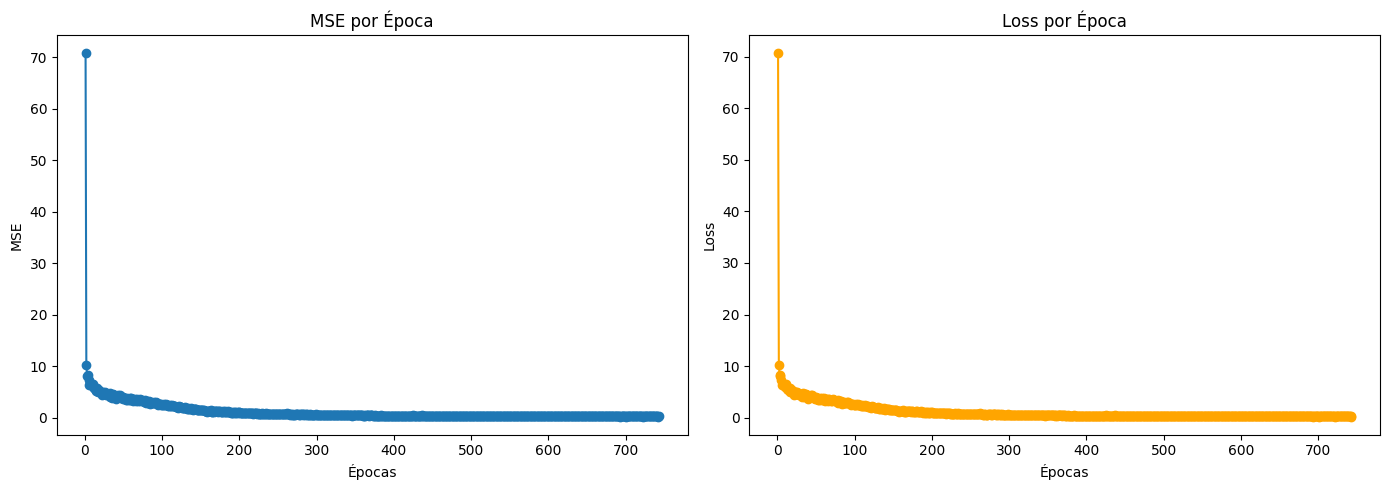

In [ ]:
# Crear modelo y optimizador
model, optimizer = get_Model(model_name, device)

# Entrenar el modelo
loss, mse = train_model(
    model,
    train_loader,
    criterion,
    optimizer,
    epochs=EPOCHS
)

# Graficos de Error Cuadrático Medio y la Función de Pérdida
plot_Training(mse, loss)

## 2.3. Network Dense Evaluation

In [ ]:
def get_Metrics(train_eval, test_eval, model_name, debug = False):
    for data in [train_eval, test_eval]:
        targets = data['targets'].cpu().numpy()
        labels  = data['labels'].cpu().numpy()
        rmse = [np.sqrt(mean_squared_error(targets, labels)),]
        r2   = [r2_score(targets, labels),]
        for ix, coord in enumerate(COLUMNS_TARGET):
            target_plot = np.array(targets)[:, ix]
            label_plot  = np.array(labels)[:, ix]
            r2.append(r2_score(target_plot, label_plot))
            rmse.append(np.sqrt(mean_squared_error(target_plot, label_plot)))
        if debug:
            print('\n',data['type'], 'DATA\n-----------')
            print('\nRMSE:     ','{:.4f}'.format(rmse[0]),  ' --> ',  end='')
            for ix,coord in enumerate(COLUMNS_TARGET):
                print('\t', coord,':','{:.4f}'.format(rmse[ix+1]),  end='')

            print('\nR^2 Score:', '{:.4f}'.format(r2[0]),  ' --> ', end='')
            for ix,coord in enumerate(COLUMNS_TARGET):
                print('\t',coord,':','{:.4f}'.format(r2[ix+1]), end='')
            print()

    return r2, rmse

In [ ]:
def show_Predictions(train_eval, test_eval, model_name, show_labels = False):

    # Crear subplots para Azimuth y Zenith
    print('\n','*'*50,'\n\t',model_name ,'\n','*'*50)
    fig, axes = plt.subplots(1, len(COLUMNS_TARGET), figsize=(14, 7))
    diag = True
    for data in [train_eval, test_eval]:
        #targets = standard_scaler.inverse_transform( data['targets'] )
        #labels = standard_scaler.inverse_transform( data['labels'] )
        targets = data['targets'].cpu().numpy()
        labels  = data['labels'].cpu().numpy()
        #print(labels.device, targets.device)
        rmse = [np.sqrt(mean_squared_error(targets, labels)),]
        r2   = [r2_score(targets, labels),]

        for ix, coord in enumerate(COLUMNS_TARGET):
            if len(COLUMNS_TARGET) > 1:
                ax = axes[ix]
                target_plot = np.array(targets)[:, ix]
                label_plot  = np.array(labels)[:, ix]
            else:
                target_plot = targets
                label_plot  = labels
                ax = axes
            if coord == 'azimuth_rad':
                plot_max = 2*np.pi
            if coord == 'zenith_rad':
                plot_max = np.pi/2
            plot_max = np.max(target_plot)
            plot_min = np.min(target_plot)
            if diag:
                ax.plot([plot_min, plot_max], [plot_min, plot_max], 'r--', label="IDEAL")

            ax.scatter(target_plot, label_plot, alpha=0.5, label= ''.join([coord,' - ', data['type']]))

            # --- COMENTADO: names y csv no se usan ---
            # if show_labels:
            #     for i, (label, csv) in enumerate(zip(data['names'], data['csv'])):
            #         texto = ''.join([label,'_',str(csv)])
            #         ax.text(target_plot[i], label_plot[i], texto, fontsize=8, ha='right')
            # ----------------------------------------

            ax.set_xlabel(''.join(['Real Target - ',coord]))
            ax.set_ylabel(''.join(['Pred Labels - ',coord]))
            ax.legend()
            ax.axhline(y=0, linestyle='--', color='gray')
            ax.axvline(x=0, linestyle='--', color='gray')
            ax.set_title(f"{model_name}: {coord} - Targets vs Labels")
            ax.grid()
            r2.append(r2_score(target_plot, label_plot))
            rmse.append(np.sqrt(mean_squared_error(target_plot, label_plot)))
        diag = False
        print('\n',data['type'], 'DATA\n-----------')
        print('\nRMSE:     ','{:.4f}'.format(rmse[0]),  ' --> ',  end='')
        for ix,coord in enumerate(COLUMNS_TARGET):
            print('\t', coord,':','{:.4f}'.format(rmse[ix+1]),  end='')

        print('\nR^2 Score:', '{:.4f}'.format(r2[0]),  ' --> ', end='')
        for ix,coord in enumerate(COLUMNS_TARGET):
            print('\t',coord,':','{:.4f}'.format(r2[ix+1]), end='')
        print()

        error = np.abs(targets[:,0] - labels[:,0])

        # Obteniendo los índices de los 5 mayores errores
        indices = np.argsort(error)[-15:]
        print('\n')
        #print(indices)

        # --- COMENTADO: dependía de names y csv ---
        # for i in indices:
        #     if i < len(data['names']) and i < len(data['csv']):
        #         print(data['names'][i], '-', data['csv'][i], '-', error[i])
        # ----------------------------------------

    plt.tight_layout()
    plt.show()




In [ ]:
# Evaluar el modelo
def evaluate_model(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    all_outputs, all_targets, all_idx = [], [], []
    # all_names, all_csv = [], []   # COMENTADO
    with torch.no_grad():
        for batch in dataloader:
            inputs, targets = batch['features'].to(device), batch['targets'].to(device)
            # names = batch['names']   # COMENTADO
            # csv   = batch['csv']     # COMENTADO
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            total_loss += loss.item()
            all_outputs.append(outputs.detach().cpu())
            all_targets.append(targets.detach().cpu())
            # all_names.append(names)          # COMENTADO
            # all_csv.append(batch['csv'])     # COMENTADO
            all_idx.append(batch['idx'])

    data = {
        'labels'  : torch.cat(all_outputs),
        'targets' : torch.cat(all_targets),
        # 'names'   : [name for sublist in all_names for name in sublist],  # COMENTADO
        # 'csv'     : [csv for sublist in all_csv for csv in sublist],      # COMENTADO
        'loss'    : total_loss / len(dataloader),
        'idx'     : torch.cat(all_idx)
    }

    return data




 ************************************************** 
	 Modelo DENSE 
 **************************************************

 TRAIN DATA
-----------

RMSE:      77.0593  --> 	 azimuth_sin : 0.3346	 azimuth_cos : 0.3121	 zenith : 133.4712
R^2 Score: -21.2526  --> 	 azimuth_sin : 0.7637	 azimuth_cos : 0.8075	 zenith : -65.3304



 TEST DATA
-----------

RMSE:      0.7036  --> 	 azimuth_sin : 0.1215	 azimuth_cos : 0.1294	 zenith : 1.2058
R^2 Score: 0.9770  --> 	 azimuth_sin : 0.9676	 azimuth_cos : 0.9684	 zenith : 0.9949




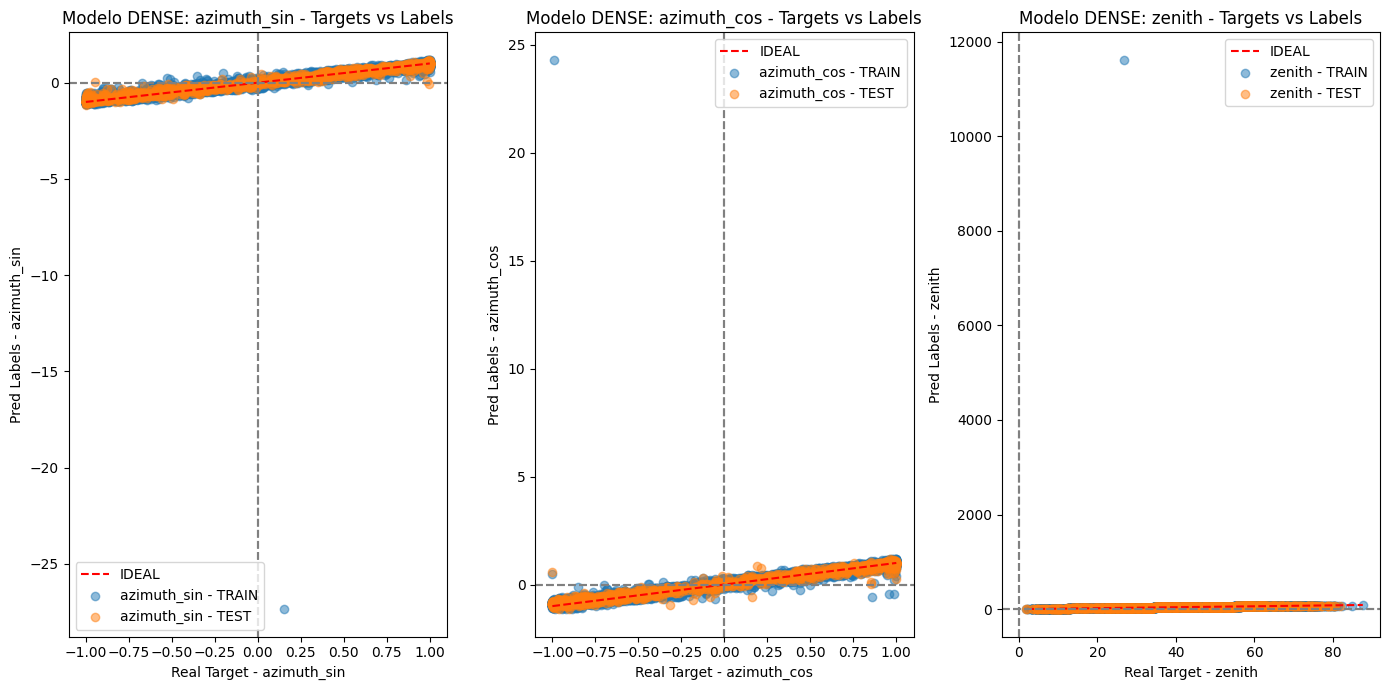

In [ ]:
test_eval = evaluate_model(model, test_loader, criterion)
test_eval['type'] = 'TEST'
train_eval = evaluate_model(model, train_loader, criterion)
train_eval['type'] = 'TRAIN'
show_Predictions(train_eval, test_eval, f"Modelo {model_name}", show_labels = False)


In [ ]:
# Guardar y cargar el modelo
torch.save(model.state_dict(), "sky_model.pth")
model.load_state_dict(torch.load("sky_model.pth", weights_only = True))


<All keys matched successfully>

In [ ]:
import numpy as np

# ============================================================
# 1) Funciones base: reconstrucción y error circular
# ============================================================

def azimuth_from_sin_cos_deg(sin_val, cos_val):
    """
    Reconstruye azimuth en grados [0, 360) a partir de sin/cos.
    sin_val, cos_val: arrays (N,) o escalares
    """
    sin_val = np.asarray(sin_val, dtype=float)
    cos_val = np.asarray(cos_val, dtype=float)

    theta_rad = np.arctan2(sin_val, cos_val)              # [-pi, pi]
    theta_deg = (np.rad2deg(theta_rad) + 360.0) % 360.0   # [0, 360)
    return theta_deg


def wrap_angle_deg(delta_deg):
    """
    Envuelve una diferencia angular a [-180, 180).
    delta_deg: array (N,) o escalar en grados
    """
    delta_deg = np.asarray(delta_deg, dtype=float)
    return (delta_deg + 180.0) % 360.0 - 180.0


def angular_errors_deg(y_true_deg, y_pred_deg):
    """
    Calcula el error circular mínimo en grados (array en [-180, 180)).
    """
    y_true_deg = np.asarray(y_true_deg, dtype=float)
    y_pred_deg = np.asarray(y_pred_deg, dtype=float)
    return wrap_angle_deg(y_pred_deg - y_true_deg)


def angular_metrics_deg(y_true_deg, y_pred_deg):
    """
    Devuelve MAE y RMSE en grados (error circular mínimo).
    """
    err = angular_errors_deg(y_true_deg, y_pred_deg)
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    return {"MAE_deg": mae, "RMSE_deg": rmse, "Bias_deg": float(np.mean(err))}


# ============================================================
# 2) Función "todo en uno" para tu salida del modelo (sin/cos)
# ============================================================

def eval_azimuth_circular_from_outputs(
    y_true,
    y_pred,
    idx_sin=0,
    idx_cos=1,
    true_is_sin_cos=True,
    y_true_azimuth_deg=None
):
    """
    Evalúa azimuth circular en grados desde salidas sin/cos.

    Parámetros
    ----------
    y_true, y_pred : np.ndarray shape (N, K)
        - Si true_is_sin_cos=True, y_true contiene sin/cos en idx_sin/idx_cos.
        - Si true_is_sin_cos=False, y_true no tiene sin/cos y debés pasar y_true_azimuth_deg.
    idx_sin, idx_cos : int
        Índices de azimuth_sin y azimuth_cos.
    true_is_sin_cos : bool
        True si y_true trae sin/cos (tu caso típico con TASK="A" actualizado).
    y_true_azimuth_deg : np.ndarray o None
        Azimuth verdadero en grados si true_is_sin_cos=False.

    Retorna
    -------
    az_true_deg, az_pred_deg, metrics_dict
    """
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # predicho
    az_pred_deg = azimuth_from_sin_cos_deg(y_pred[:, idx_sin], y_pred[:, idx_cos])

    # verdadero
    if true_is_sin_cos:
        az_true_deg = azimuth_from_sin_cos_deg(y_true[:, idx_sin], y_true[:, idx_cos])
    else:
        if y_true_azimuth_deg is None:
            raise ValueError("Pasá y_true_azimuth_deg si true_is_sin_cos=False.")
        az_true_deg = (np.asarray(y_true_azimuth_deg, dtype=float) + 360.0) % 360.0

    metrics = angular_metrics_deg(az_true_deg, az_pred_deg)
    return az_true_deg, az_pred_deg, metrics


# ============================================================
# 3) EJEMPLO DE LLAMADA (pegá tus arrays reales acá)
# ============================================================
if __name__ == "__main__":
    # Ejemplo dummy: reemplazá por tus arrays reales (N,3)
    # y_true_np = ...  # [az_sin_true, az_cos_true, zenith_true]
    # y_pred_np = ...  # [az_sin_pred, az_cos_pred, zenith_pred]

    # Demo rápida (borrá esto cuando uses tus datos)
    N = 5
    az_true_demo = np.array([358, 2, 45, 180, 270], dtype=float)
    sin_true = np.sin(np.deg2rad(az_true_demo))
    cos_true = np.cos(np.deg2rad(az_true_demo))

    # Simulo pred con un pequeño error angular
    az_pred_demo = (az_true_demo + np.array([5, -4, 3, -2, 6])) % 360
    sin_pred = np.sin(np.deg2rad(az_pred_demo))
    cos_pred = np.cos(np.deg2rad(az_pred_demo))

    y_true_np = np.stack([sin_true, cos_true, np.zeros(N)], axis=1)
    y_pred_np = np.stack([sin_pred, cos_pred, np.zeros(N)], axis=1)

    az_true_deg, az_pred_deg, met = eval_azimuth_circular_from_outputs(
        y_true=y_true_np,
        y_pred=y_pred_np,
        idx_sin=0,
        idx_cos=1,
        true_is_sin_cos=True
    )

    print("Azimuth true (deg):", az_true_deg)
    print("Azimuth pred (deg):", az_pred_deg)
    print("Métricas angulares:", met)


Azimuth true (deg): [358.   2.  45. 180. 270.]
Azimuth pred (deg): [  3. 358.  48. 178. 276.]
Métricas angulares: {'MAE_deg': 4.0, 'RMSE_deg': 4.242640687119285, 'Bias_deg': 1.6}


In [ ]:
az_true_deg, az_pred_deg, met = eval_azimuth_circular_from_outputs(y_true_np, y_pred_np)
print(met)


{'MAE_deg': 4.0, 'RMSE_deg': 4.242640687119285, 'Bias_deg': 1.6}


Métricas globales azimuth (circular): {'MAE_deg': 2.6138288539024623, 'RMSE_deg': 3.853294991360621, 'Bias_deg': 0.07503703140080095}


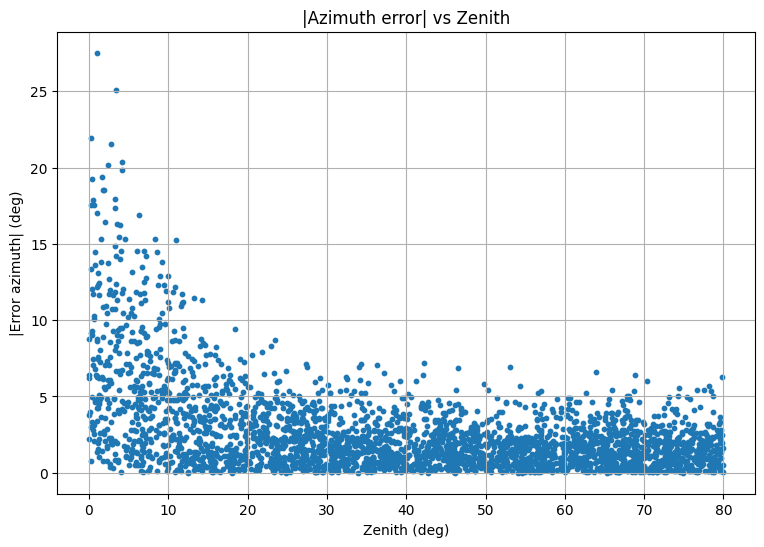

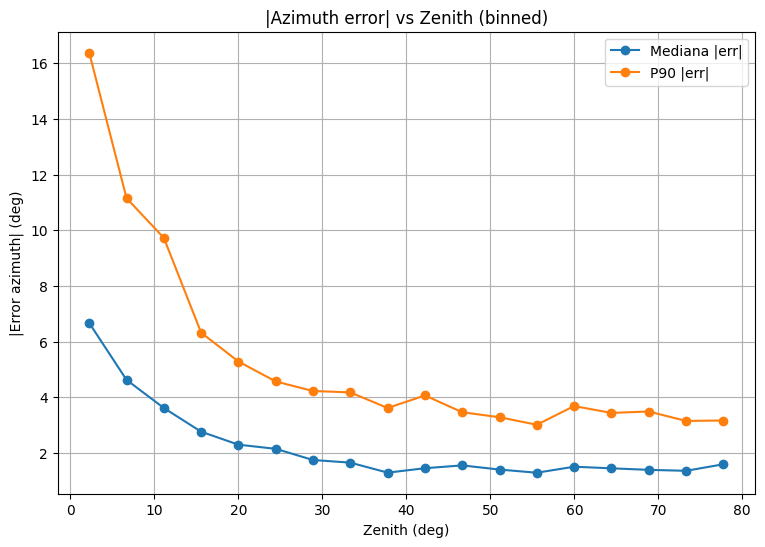


Resumen por bins (zenith):
  Bin 01: z~  2.24  n= 174  med=  6.67  p90= 16.38
  Bin 02: z~  6.68  n= 171  med=  4.62  p90= 11.15
  Bin 03: z~ 11.12  n= 170  med=  3.61  p90=  9.72
  Bin 04: z~ 15.56  n= 156  med=  2.76  p90=  6.32
  Bin 05: z~ 20.00  n= 151  med=  2.29  p90=  5.28
  Bin 06: z~ 24.44  n= 168  med=  2.14  p90=  4.57
  Bin 07: z~ 28.89  n= 191  med=  1.74  p90=  4.22
  Bin 08: z~ 33.33  n= 178  med=  1.65  p90=  4.17
  Bin 09: z~ 37.77  n= 165  med=  1.29  p90=  3.61
  Bin 10: z~ 42.21  n= 155  med=  1.45  p90=  4.06
  Bin 11: z~ 46.65  n= 179  med=  1.55  p90=  3.46
  Bin 12: z~ 51.09  n= 142  med=  1.40  p90=  3.28
  Bin 13: z~ 55.54  n= 177  med=  1.29  p90=  3.01
  Bin 14: z~ 59.98  n= 147  med=  1.50  p90=  3.68
  Bin 15: z~ 64.42  n= 170  med=  1.44  p90=  3.44
  Bin 16: z~ 68.86  n= 171  med=  1.39  p90=  3.49
  Bin 17: z~ 73.30  n= 177  med=  1.35  p90=  3.15
  Bin 18: z~ 77.74  n= 157  med=  1.59  p90=  3.16


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ============================================================
# 1) Funciones: azimuth desde sin/cos + wrap + métricas
# ============================================================

def azimuth_from_sin_cos_deg(az_sin, az_cos):
    """
    sin/cos -> azimuth en grados [0, 360)
    """
    az_sin = np.asarray(az_sin, dtype=float)
    az_cos = np.asarray(az_cos, dtype=float)
    az_rad = np.arctan2(az_sin, az_cos)              # [-pi, pi]
    az_deg = (np.rad2deg(az_rad) + 360.0) % 360.0    # [0, 360)
    return az_deg


def wrap_angle_deg(delta_deg):
    """
    Envuelve diferencia angular a [-180, 180)
    """
    delta_deg = np.asarray(delta_deg, dtype=float)
    return (delta_deg + 180.0) % 360.0 - 180.0


def angular_error_deg(az_true_deg, az_pred_deg):
    """
    Error circular mínimo en grados (array), en [-180, 180)
    """
    return wrap_angle_deg(np.asarray(az_pred_deg, float) - np.asarray(az_true_deg, float))


def angular_metrics_deg(az_true_deg, az_pred_deg):
    """
    MAE/RMSE/Bias en grados usando error circular mínimo
    """
    err = angular_error_deg(az_true_deg, az_pred_deg)
    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err**2)))
    bias = float(np.mean(err))
    return {"MAE_deg": mae, "RMSE_deg": rmse, "Bias_deg": bias}


# ============================================================
# 2) Gráfico: error de azimuth vs zenith
# ============================================================

def plot_error_vs_zenith(
    y_true,
    y_pred,
    idx_sin=0,
    idx_cos=1,
    idx_zenith=2,
    zenith_in_degrees=True,
    title="|Azimuth error| vs Zenith",
    bins=18
):
    """
    y_true, y_pred: np.ndarray (N,K)
    Asume que y_true/y_pred contienen:
      - azimuth_sin en idx_sin
      - azimuth_cos en idx_cos
      - zenith en idx_zenith (grados, idealmente sin escalar)
    """

    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)

    # Reconstruyo azimuth en grados
    az_true_deg = azimuth_from_sin_cos_deg(y_true[:, idx_sin], y_true[:, idx_cos])
    az_pred_deg = azimuth_from_sin_cos_deg(y_pred[:, idx_sin], y_pred[:, idx_cos])

    # Error circular (abs)
    err_deg = angular_error_deg(az_true_deg, az_pred_deg)
    abs_err_deg = np.abs(err_deg)

    # Zenith (para eje X)
    zen = y_true[:, idx_zenith].astype(float)

    # Si zenith NO está en grados (por ejemplo escalado), esto no sirve.
    # Lo dejo como warning explícito:
    if not zenith_in_degrees:
        print("[WARN] zenith_in_degrees=False: estás graficando zenith en escala no-grados.")

    # Limpieza de NaNs / inf
    mask = np.isfinite(zen) & np.isfinite(abs_err_deg)
    zen = zen[mask]
    abs_err_deg = abs_err_deg[mask]

    # Métricas globales (azimuth)
    met = angular_metrics_deg(az_true_deg[mask], az_pred_deg[mask])
    print("Métricas globales azimuth (circular):", met)

    # ===== Scatter =====
    plt.figure(figsize=(9, 6))
    plt.scatter(zen, abs_err_deg, s=10)
    plt.xlabel("Zenith (deg)" if zenith_in_degrees else "Zenith (scaled)")
    plt.ylabel("|Error azimuth| (deg)")
    plt.title(title)
    plt.grid(True)
    plt.show()

    # ===== Binned curve (mediana y p90) =====
    if bins is not None and bins > 1:
        # Defino bins en zenith
        zmin, zmax = float(np.min(zen)), float(np.max(zen))
        edges = np.linspace(zmin, zmax, bins + 1)
        centers = 0.5 * (edges[:-1] + edges[1:])

        med = np.full(bins, np.nan)
        p90 = np.full(bins, np.nan)
        counts = np.zeros(bins, dtype=int)

        for i in range(bins):
            m = (zen >= edges[i]) & (zen < edges[i+1])
            counts[i] = int(np.sum(m))
            if counts[i] >= 10:  # umbral mínimo para estadística razonable
                med[i] = np.nanmedian(abs_err_deg[m])
                p90[i] = np.nanpercentile(abs_err_deg[m], 90)

        plt.figure(figsize=(9, 6))
        plt.plot(centers, med, marker='o', label="Mediana |err|")
        plt.plot(centers, p90, marker='o', label="P90 |err|")
        plt.xlabel("Zenith (deg)" if zenith_in_degrees else "Zenith (scaled)")
        plt.ylabel("|Error azimuth| (deg)")
        plt.title(title + " (binned)")
        plt.grid(True)
        plt.legend()
        plt.show()

        # Print resumen bins
        print("\nResumen por bins (zenith):")
        for i in range(bins):
            if counts[i] > 0:
                print(f"  Bin {i+1:02d}: z~{centers[i]:6.2f}  n={counts[i]:4d}  med={med[i]:6.2f}  p90={p90[i]:6.2f}")


# ============================================================
# 3) LLAMADA (PEGÁ TUS ARRAYS REALES AQUÍ)
# ============================================================
if __name__ == "__main__":
    """
    USO REAL:
      - y_true_np: (N,3) con orden [azimuth_sin, azimuth_cos, zenith]
      - y_pred_np: (N,3) con el mismo orden

    IMPORTANTE:
      - Si escalaste 'zenith' con StandardScaler en tu pipeline, este gráfico NO será en grados.
        En ese caso, pasá el zenith sin escalar (o invertí el scaler).
    """

    # ====== EJEMPLO DUMMY (reemplazar por tu data real) ======
    N = 3000
    rng = np.random.default_rng(0)

    # Simulo zenith 0-80
    zen_true = rng.uniform(0, 80, size=N)

    # Simulo azimuth verdadero
    az_true = rng.uniform(0, 360, size=N)
    sin_true = np.sin(np.deg2rad(az_true))
    cos_true = np.cos(np.deg2rad(az_true))

    # Simulo error angular que crece cerca del zenith pequeño (ejemplo geométrico)
    # error_std mayor cuando zenith es pequeño
    err_std = 2.0 + 10.0 * np.exp(-zen_true / 10.0)
    az_pred = (az_true + rng.normal(0, err_std, size=N)) % 360
    sin_pred = np.sin(np.deg2rad(az_pred))
    cos_pred = np.cos(np.deg2rad(az_pred))

    y_true_np = np.stack([sin_true, cos_true, zen_true], axis=1)
    y_pred_np = np.stack([sin_pred, cos_pred, zen_true], axis=1)  # zenith perfecto solo para demo

    # ====== Gráfico ======
    plot_error_vs_zenith(
        y_true=y_true_np,
        y_pred=y_pred_np,
        idx_sin=0,
        idx_cos=1,
        idx_zenith=2,
        zenith_in_degrees=True,
        title="|Azimuth error| vs Zenith",
        bins=18
    )


## 2.4. Simulation Loop

In [ ]:
r2_list, rmse_list, loss_list, mse_list = [], [], [], []
train_eval_list, test_eval_list = [], []
for loop in range(LOOPS):
    model, optimizer = get_Model(model_name, device)
    loss, mse = train_model(model, train_loader, criterion, optimizer, epochs=EPOCHS)
    test_eval = evaluate_model(model, test_loader, criterion)
    test_eval['type'] = 'TEST'
    train_eval = evaluate_model(model, train_loader, criterion)
    train_eval['type'] = 'TRAIN'
    r2, rmse = get_Metrics(train_eval, test_eval, f"Modelo {model_name}", debug = True)
print(r2_list, rmse_list)

Epoch 1/1000, Loss: 74.7473, MSE: 74.8541
Epoch 101/1000, Loss: 2.5166, MSE: 2.5149
Epoch 201/1000, Loss: 1.1183, MSE: 1.1182
Epoch 301/1000, Loss: 0.6924, MSE: 0.6923
Epoch 401/1000, Loss: 0.4425, MSE: 0.4426
Epoch 501/1000, Loss: 0.3344, MSE: 0.3347
Epoch 601/1000, Loss: 0.2741, MSE: 0.2741
Epoch 701/1000, Loss: 0.2907, MSE: 0.2907

⛔ Early stopping activado en epoch 746

 TRAIN DATA
-----------

RMSE:      18.9605  --> 	 azimuth_sin : 0.5430	 azimuth_cos : 0.6328	 zenith : 32.8301
R^2 Score: -0.8089  --> 	 azimuth_sin : 0.3777	 azimuth_cos : 0.2087	 zenith : -3.0131

 TEST DATA
-----------

RMSE:      0.9670  --> 	 azimuth_sin : 0.1087	 azimuth_cos : 0.1322	 zenith : 1.6661
R^2 Score: 0.9771  --> 	 azimuth_sin : 0.9741	 azimuth_cos : 0.9670	 zenith : 0.9902
Epoch 1/1000, Loss: 70.7053, MSE: 70.8178
Epoch 101/1000, Loss: 2.9315, MSE: 2.9324
Epoch 201/1000, Loss: 1.1540, MSE: 1.1537
Epoch 301/1000, Loss: 0.6565, MSE: 0.6569
Epoch 401/1000, Loss: 0.4603, MSE: 0.4601
Epoch 501/1000, Los

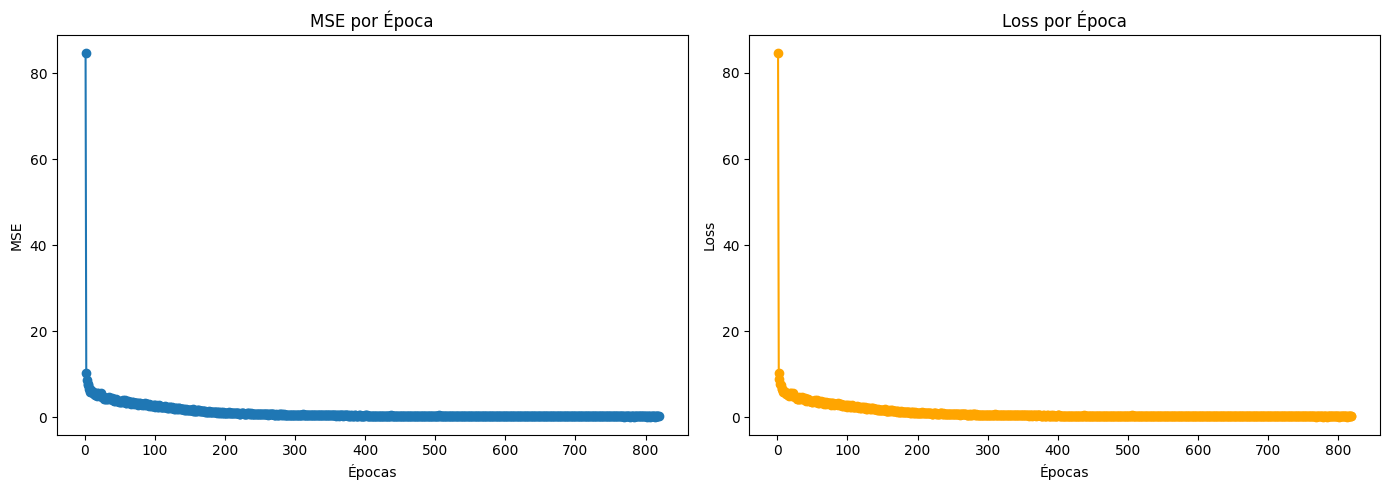


 ************************************************** 
	 Modelo DENSE 
 **************************************************

 TRAIN DATA
-----------

RMSE:      163.8526  --> 	 azimuth_sin : 8.0919	 azimuth_cos : 6.7945	 zenith : 283.6054
R^2 Score: -175.2946  --> 	 azimuth_sin : -137.1983	 azimuth_cos : -90.2124	 zenith : -298.4791



 TEST DATA
-----------

RMSE:      0.8440  --> 	 azimuth_sin : 0.1084	 azimuth_cos : 0.1177	 zenith : 1.4531
R^2 Score: 0.9802  --> 	 azimuth_sin : 0.9742	 azimuth_cos : 0.9739	 zenith : 0.9926




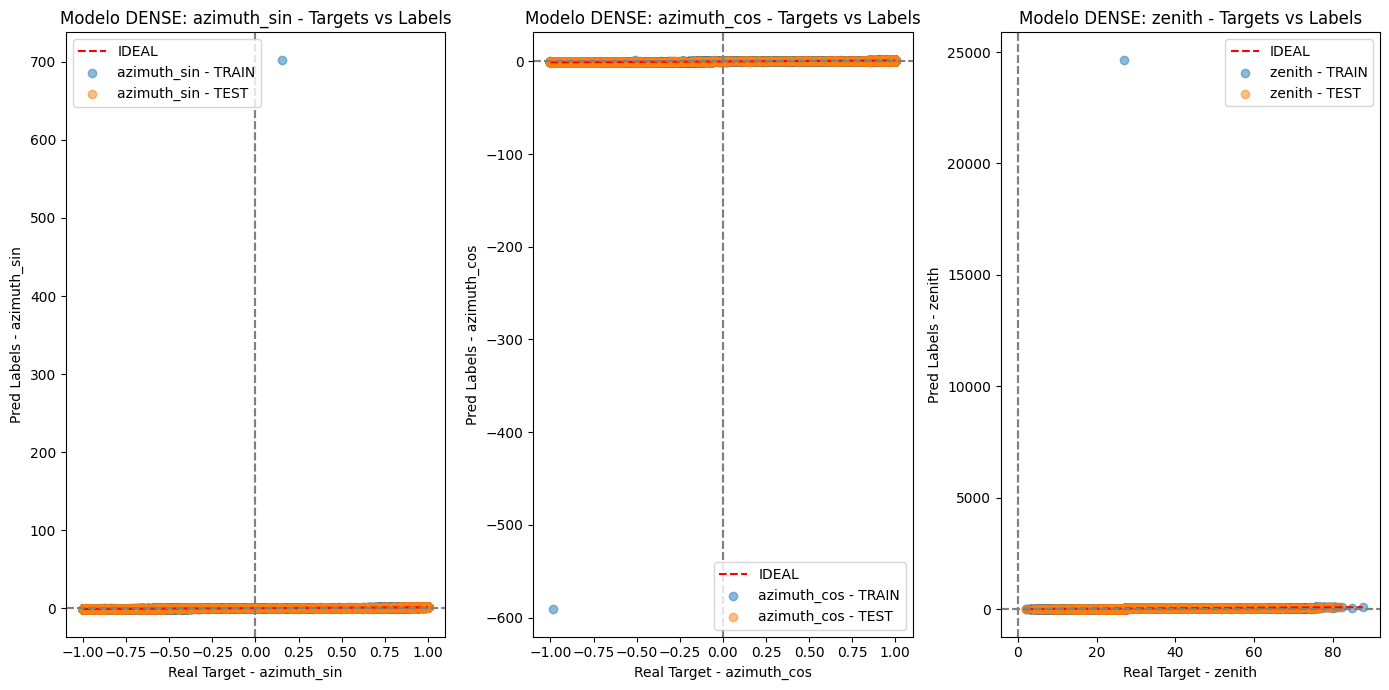

In [ ]:
plot_Training(mse, loss)
show_Predictions(train_eval, test_eval, f"Modelo {model_name}", show_labels = False)